# Predicting the popularity of news articles

implement a regression model to predict the popularity of new articles (the number of times they will be shared online based on
about 60 features.

In [376]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("srikaranelakurthy/online-news-popularity")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/srikaranelakurthy/online-news-popularity/versions/1


In [377]:
import warnings
warnings.filterwarnings('ignore')

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# From kaggle:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



## Applying EDA
Perform exploratory data analysis on the dataset <br><br>

* ### Reading data:

In [378]:
pop_df = pd.read_csv('/root/.cache/kagglehub/datasets/srikaranelakurthy/online-news-popularity/versions/1/OnlineNewsPopularity.csv')
print("Dimension of data frame:", pop_df.shape)
pop_df.head()

Dimension of data frame: (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [379]:
pop_df.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [380]:
pop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

### preparation and extraxtion:

In [381]:
pop_df.url.shape[0] == pop_df.url.nunique()

True

#### Inference:
As we khow each article have a unique URL and in this case, URLs generally won't be significant for our regression model. However, we might consider extracting specific information from URLs like Date Information. Extracting dates from URLs (if available) could allow us to create features around article age or seasonality, potentially capturing trends in article popularity over time.
Apply just year and month:

In [382]:
ArticleYear = pop_df['url'].apply(lambda url : url.split('/')[3])
ArticleMonth = pop_df['url'].apply(lambda url : url.split('/')[4])
pop_df.insert(1,"ArticleYear",ArticleYear)
pop_df.insert(2,"ArticleMonth",ArticleMonth)
pop_df.drop(['url'],axis="columns",inplace=True)
pop_df.head()

,ArticleYear,ArticleMonth,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,2013,01,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,2013,01,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,2013,01,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,2013,01,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,2013,01,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [383]:
print(pop_df.ArticleYear.unique())
print(pop_df.ArticleMonth.unique())

['2013' '2014']
['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12']


In [384]:
pop_df.columns

Index(['ArticleYear', 'ArticleMonth', ' timedelta', ' n_tokens_title',
       ' n_tokens_content', ' n_unique_tokens', ' n_non_stop_words',
       ' n_non_stop_unique_tokens', ' num_hrefs', ' num_self_hrefs',
       ' num_imgs', ' num_videos', ' average_token_length', ' num_keywords',
       ' data_channel_is_lifestyle', ' data_channel_is_entertainment',
       ' data_channel_is_bus', ' data_channel_is_socmed',
       ' data_channel_is_tech', ' data_channel_is_world', ' kw_min_min',
       ' kw_max_min', ' kw_avg_min', ' kw_min_max', ' kw_max_max',
       ' kw_avg_max', ' kw_min_avg', ' kw_max_avg', ' kw_avg_avg',
       ' self_reference_min_shares', ' self_reference_max_shares',
       ' self_reference_avg_sharess', ' weekday_is_monday',
       ' weekday_is_tuesday', ' weekday_is_wednesday', ' weekday_is_thursday',
       ' weekday_is_friday', ' weekday_is_saturday', ' weekday_is_sunday',
       ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02', ' LDA_03', ' LDA_04',
       ' global_subj

In [385]:
# Remove all extra spaces at the beginning of the column names
pop_df.columns = pop_df.columns.str.strip()

### Visulisation

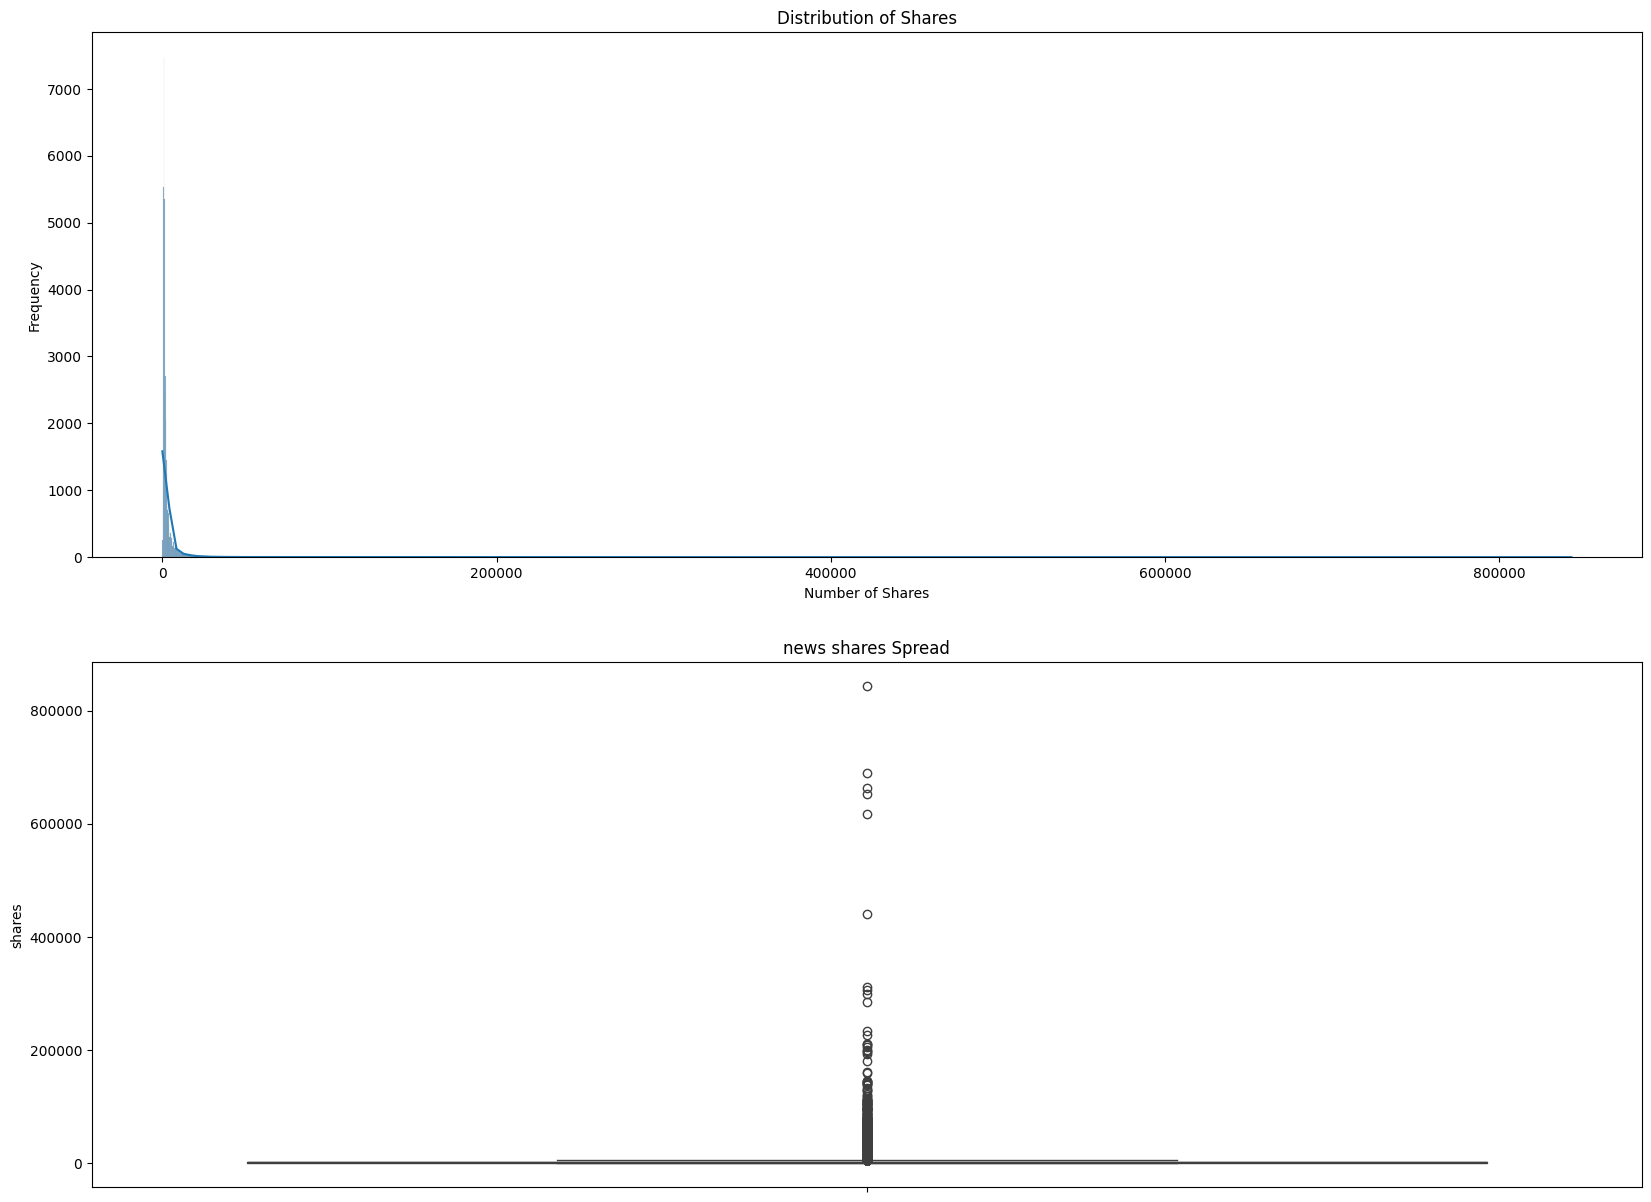

In [386]:
plt.figure(figsize=(20,15))

plt.subplot(2,1,1)
sns.histplot(pop_df.shares, bins=3000, kde=True)
plt.title('Distribution of Shares')
plt.xlabel('Number of Shares')
plt.ylabel('Frequency')

plt.subplot(2,1,2)
plt.title('news shares Spread')
sns.boxplot(y=pop_df.shares)

plt.show()

#### Inference :

The distribution and box plot we created show that the "shares" feature is highly skewed, with most data concentrated at the lower end and a few extreme outliers at the higher end. This skewness makes it challenging to interpret the data from the plots as they currently appear.
We try ways to improve interpretation:

In [387]:
# Define the 95th percentile threshold for "shares"
cap_value = np.percentile(pop_df.shares, 95)

pop_df['shares_capped'] = np.where(pop_df.shares > cap_value, cap_value, pop_df.shares)

pop_df_filtered = pop_df[pop_df.shares <= cap_value]


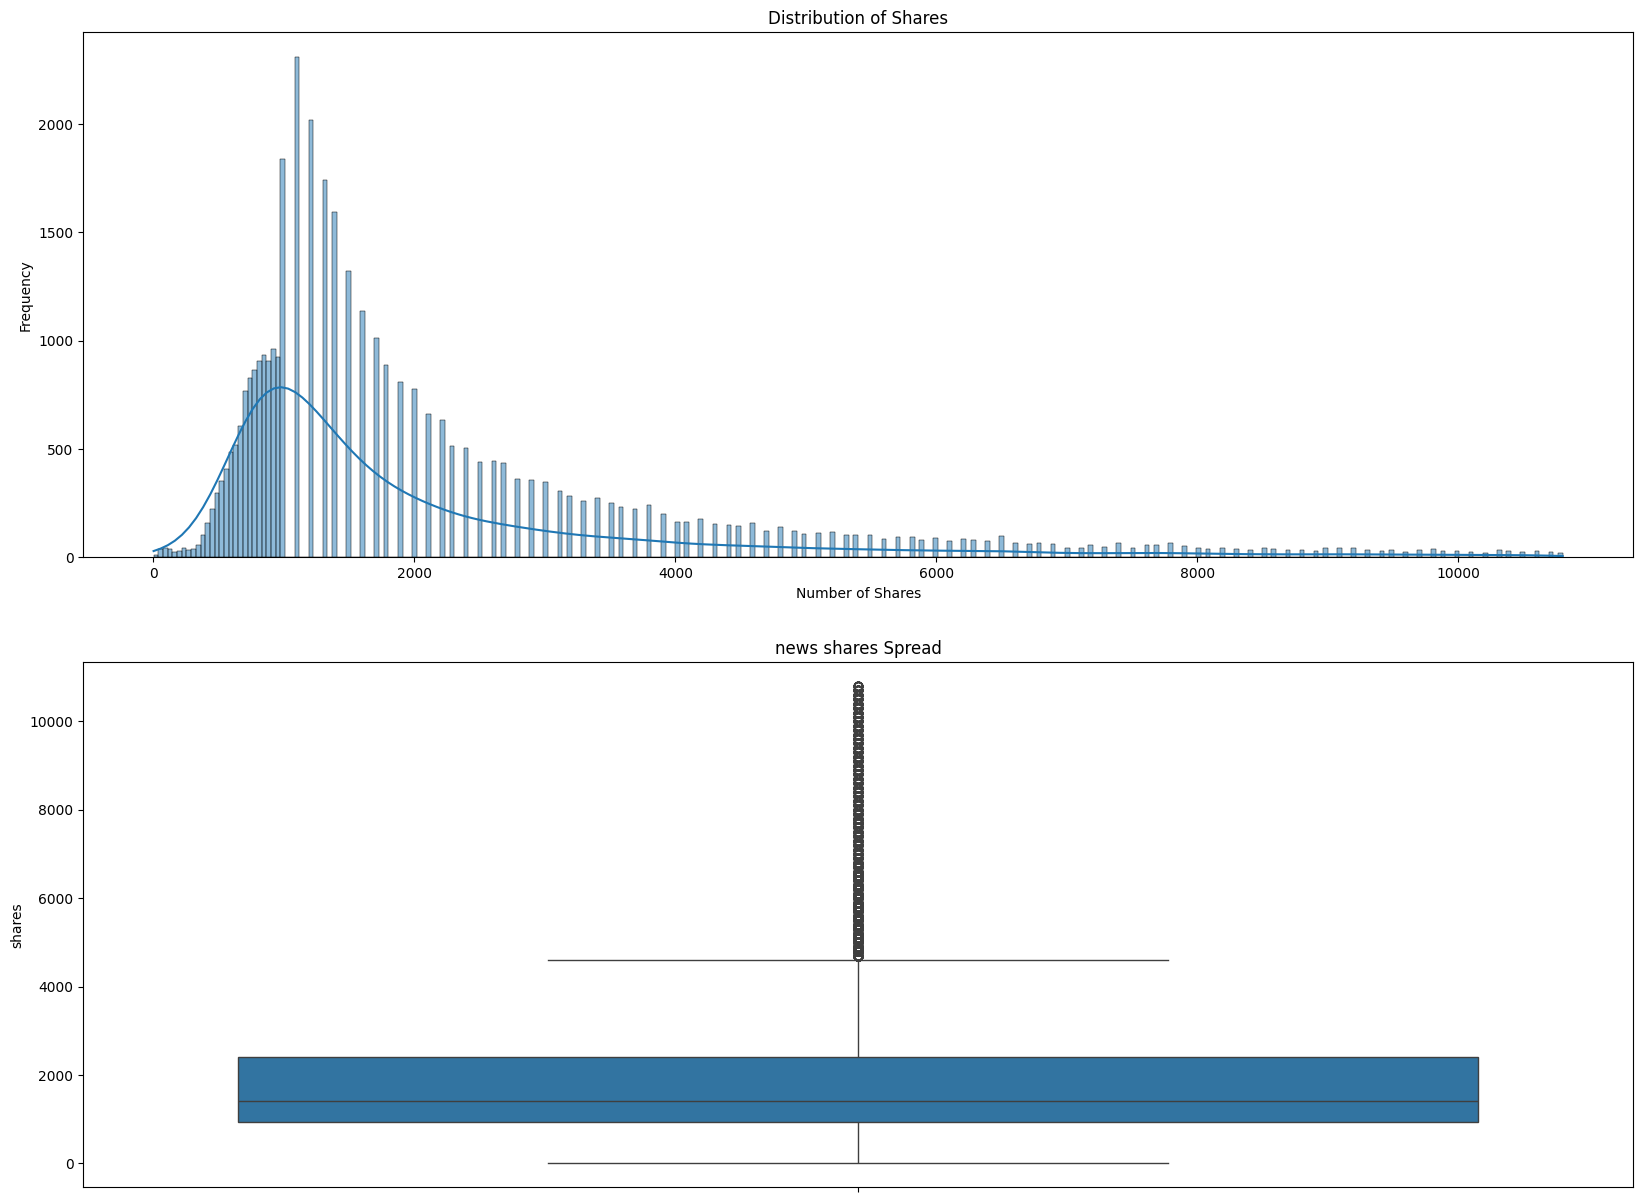

In [388]:
# Plot the filtered shares
plt.figure(figsize=(20,15))

plt.subplot(2,1,1)
sns.histplot(pop_df_filtered.shares , bins=300, kde=True)
plt.title('Distribution of Shares')
plt.xlabel('Number of Shares')
plt.ylabel('Frequency')

plt.subplot(2,1,2)
plt.title('news shares Spread')
sns.boxplot(y=pop_df_filtered.shares )

plt.show()

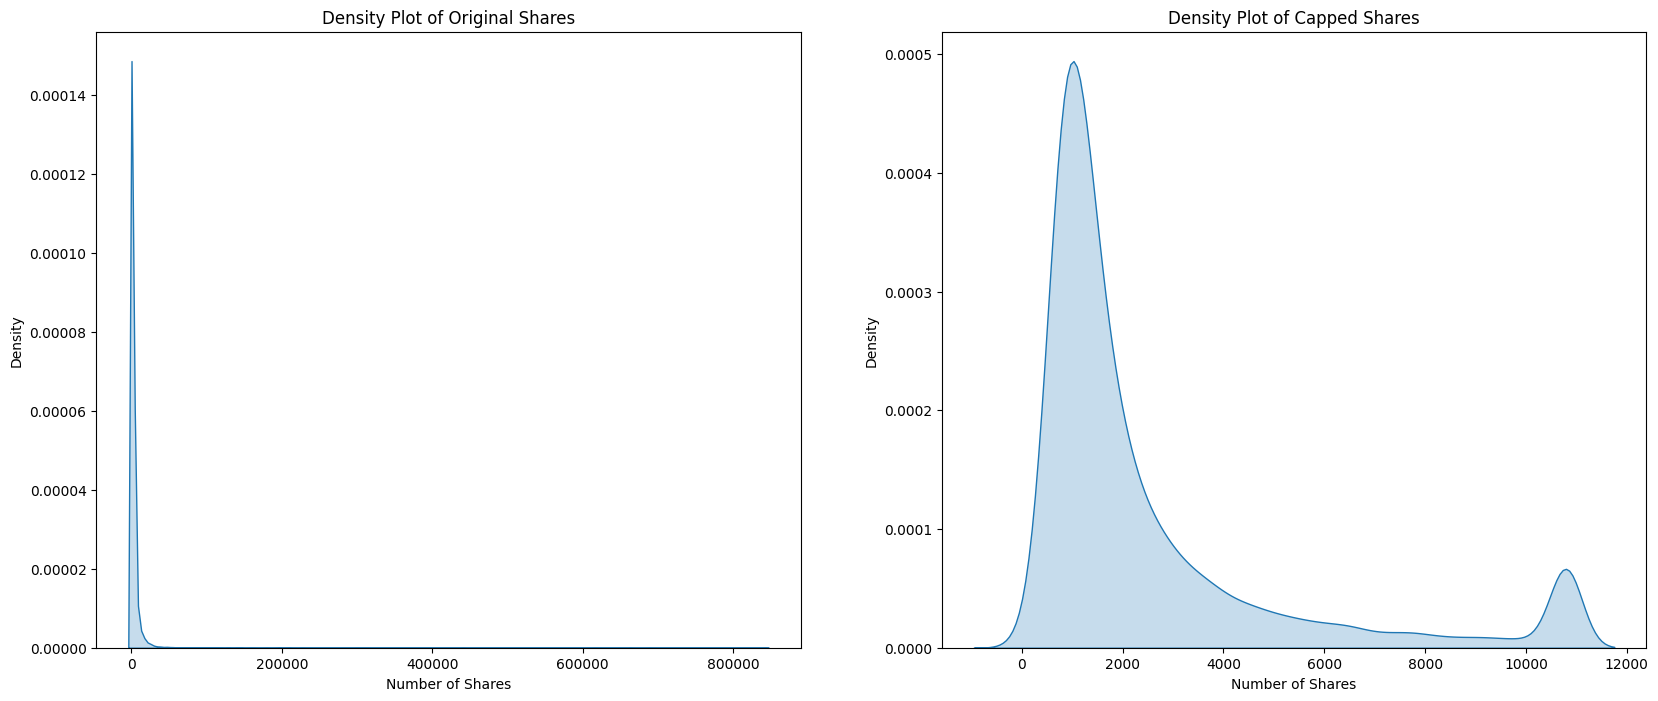

In [389]:
# Plot density of capped values of shares
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
sns.kdeplot(pop_df.shares, shade=True)
plt.title('Density Plot of Original Shares')
plt.xlabel('Number of Shares')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
sns.kdeplot(pop_df.shares_capped, shade=True)
plt.title('Density Plot of Capped Shares')
plt.xlabel('Number of Shares')
plt.ylabel('Density')

plt.show()


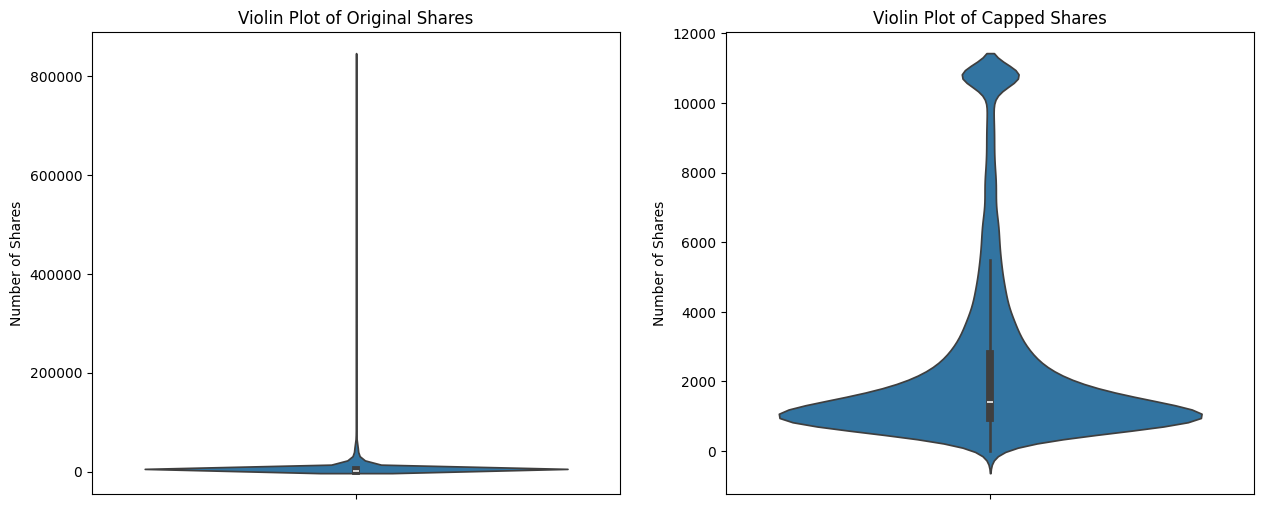

In [390]:
# Plot violin
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.violinplot(y=pop_df.shares)
plt.title('Violin Plot of Original Shares')
plt.ylabel('Number of Shares')

plt.subplot(1, 2, 2)
sns.violinplot(y=pop_df.shares_capped)
plt.title('Violin Plot of Capped Shares')
plt.ylabel('Number of Shares')

plt.show()


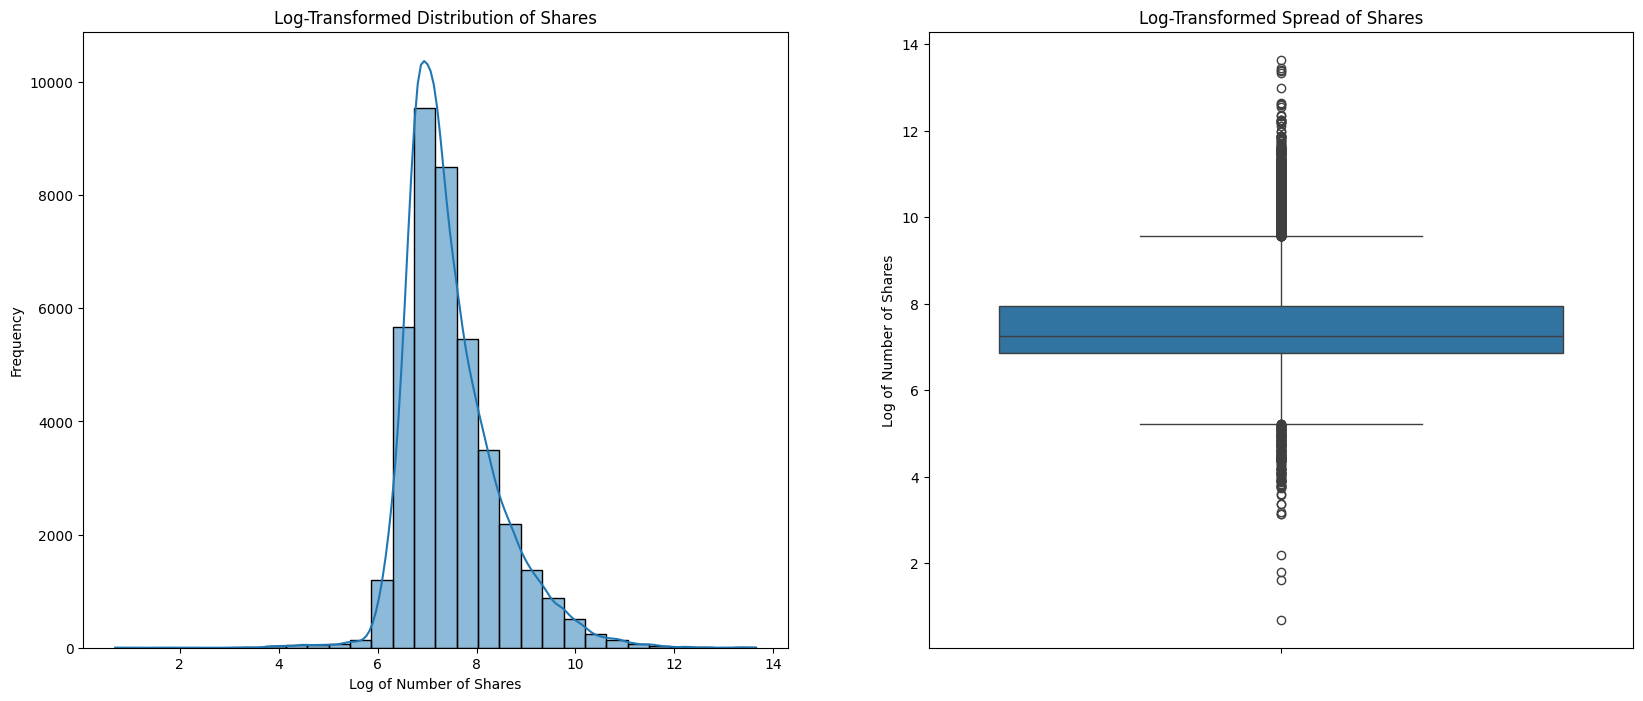

In [391]:
# Use Log-transformed plots
pop_df['log_shares'] = np.log1p(pop_df['shares'])
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
sns.histplot(pop_df.log_shares, bins=30, kde=True)
plt.title('Log-Transformed Distribution of Shares')
plt.xlabel('Log of Number of Shares')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=pop_df.log_shares)
plt.title('Log-Transformed Spread of Shares')
plt.ylabel('Log of Number of Shares')

plt.show()

In [392]:
pop_df.shares.describe(percentiles = [0.25,0.50,0.75,0.85,0.90,1])

,shares
count,39644.000000
mean,3395.380184
std,11626.950749
min,1.000000
25%,946.000000
50%,1400.000000
75%,2800.000000
85%,4400.000000
90%,6200.000000
100%,843300.000000


#### Inference :

1. The most shares in the dataset are low(around 0 to 2000).
2. There is a significant difference between the mean and the median of the share distribution.
3. The data points are far spread out from the mean, which indicates a high variance in the car shares.(85% of the shares are below 4400, whereas the remaining 15% are between 4400 and 843300)

In [393]:
# Removing unnecessary feature we made
pop_df.drop(['log_shares'],axis="columns",inplace=True)
pop_df.drop(['shares_capped'],axis="columns",inplace=True)

####  Visualising Categorical Data

    - data_channel_is_lifestyle: Is data channel 'Lifestyle'? (Binary)
    - data_channel_is_entertainment: Is data channel 'Entertainment'? (Binary)
    - data_channel_is_bus: Is data channel 'Business'? (Binary)
    - data_channel_is_socmed: Is data channel 'Social Media'? (Binary)
    - data_channel_is_tech: Is data channel 'Tech'? (Binary)
    - data_channel_is_world: Is data channel 'World'? (Binary)

    - weekday_is_monday: Was the article published on a Monday? (Binary)
    - weekday_is_tuesday: Was the article published on a Tuesday? (Binary)
    - weekday_is_wednesday: Was the article published on a Wednesday? (Binary)
    - weekday_is_thursday: Was the article published on a Thursday? (Binary)
    - weekday_is_friday: Was the article published on a Friday? (Binary)
    - weekday_is_saturday: Was the article published on a Saturday? (Binary)
    - weekday_is_sunday: Was the article published on a Sunday? (Binary)
    - is_weekend: Was the article published on the weekend? (Binary)

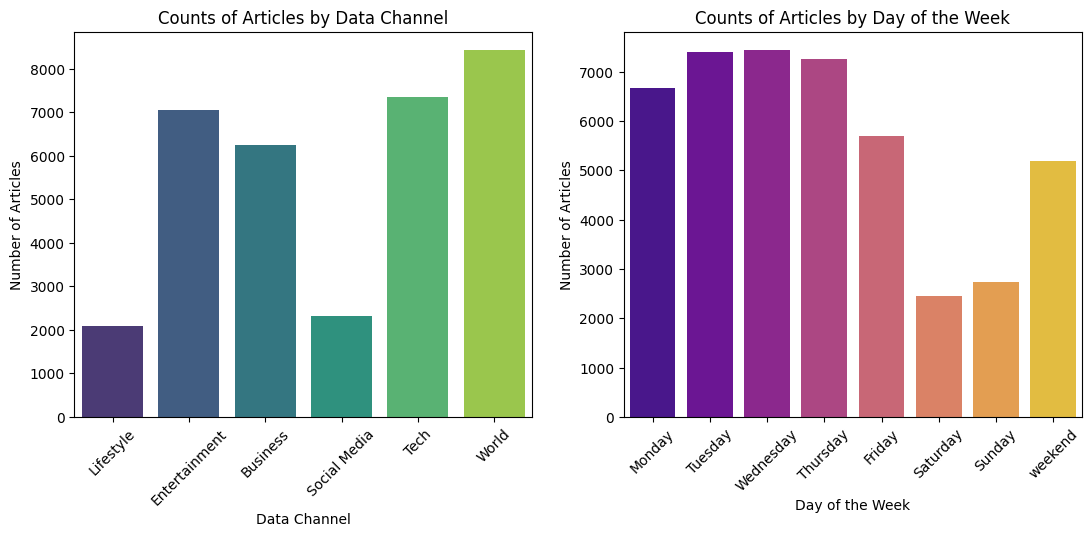

In [394]:
data_channel_types = [
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed',
    'data_channel_is_tech', 'data_channel_is_world'
]
data_channel_labels = [
    'Lifestyle', 'Entertainment', 'Business', 'Social Media', 'Tech', 'World'
]

weekdays = [
    'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
    'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
    'weekday_is_sunday', 'is_weekend'
]
weekday_labels = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday',
    'Saturday', 'Sunday', 'weekend'
]


plt.figure(figsize=(13, 5))

# Count plot for data channels
plt.subplot(1, 2, 1)
data_channel_counts = pop_df[data_channel_types].sum()
sns.barplot(x=data_channel_labels, y=data_channel_counts.values, palette="viridis")
plt.title('Counts of Articles by Data Channel')
plt.ylabel('Number of Articles')
plt.xlabel('Data Channel')
plt.xticks(rotation=45)

# Count plot for weekdays
plt.subplot(1, 2, 2)
weekday_counts = pop_df[weekdays].sum()
sns.barplot(x=weekday_labels, y=weekday_counts.values, palette="plasma")
plt.title('Counts of Articles by Day of the Week')
plt.ylabel('Number of Articles')
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)

plt.show()



#### Inference :

Articles published more at the beginning of the week and the most published channels are "world", "tech" , "entertainment" and "bus"

<br><br>

#### Using filtered (95%) popularity dataframe to visualising:

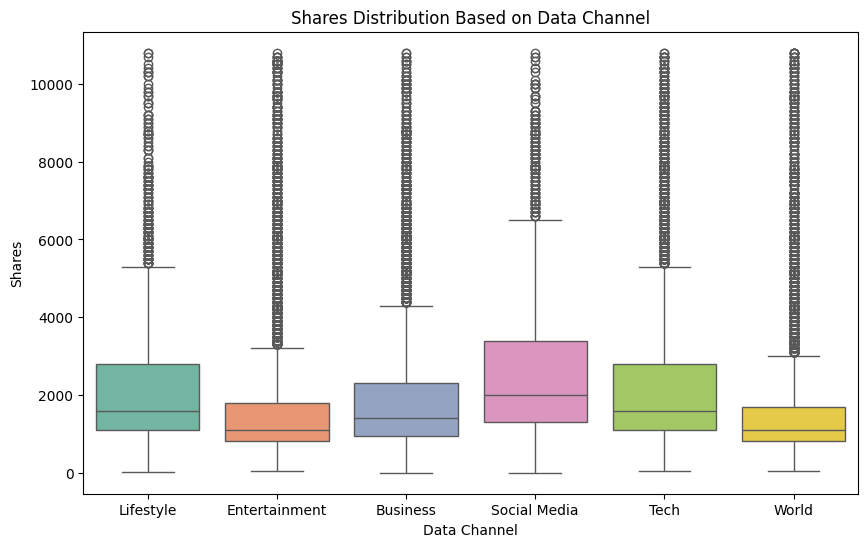

In [395]:
# melting data frame
melted_pop_df = pd.melt(pop_df_filtered, id_vars=['shares'], value_vars=[
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed',
    'data_channel_is_tech', 'data_channel_is_world'
], var_name='data_channel', value_name='channel_active')

melted_pop_df = melted_pop_df[melted_pop_df['channel_active'] == 1]

# Map the column names to more readable labels
channel_mapping = {
    'data_channel_is_lifestyle': 'Lifestyle',
    'data_channel_is_entertainment': 'Entertainment',
    'data_channel_is_bus': 'Business',
    'data_channel_is_socmed': 'Social Media',
    'data_channel_is_tech': 'Tech',
    'data_channel_is_world': 'World'
}
melted_pop_df['data_channel'] = melted_pop_df['data_channel'].map(channel_mapping)

# Plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='data_channel', y='shares', data=melted_pop_df, palette='Set2')
plt.title('Shares Distribution Based on Data Channel')
plt.xlabel('Data Channel')
plt.ylabel('Shares')

plt.show()


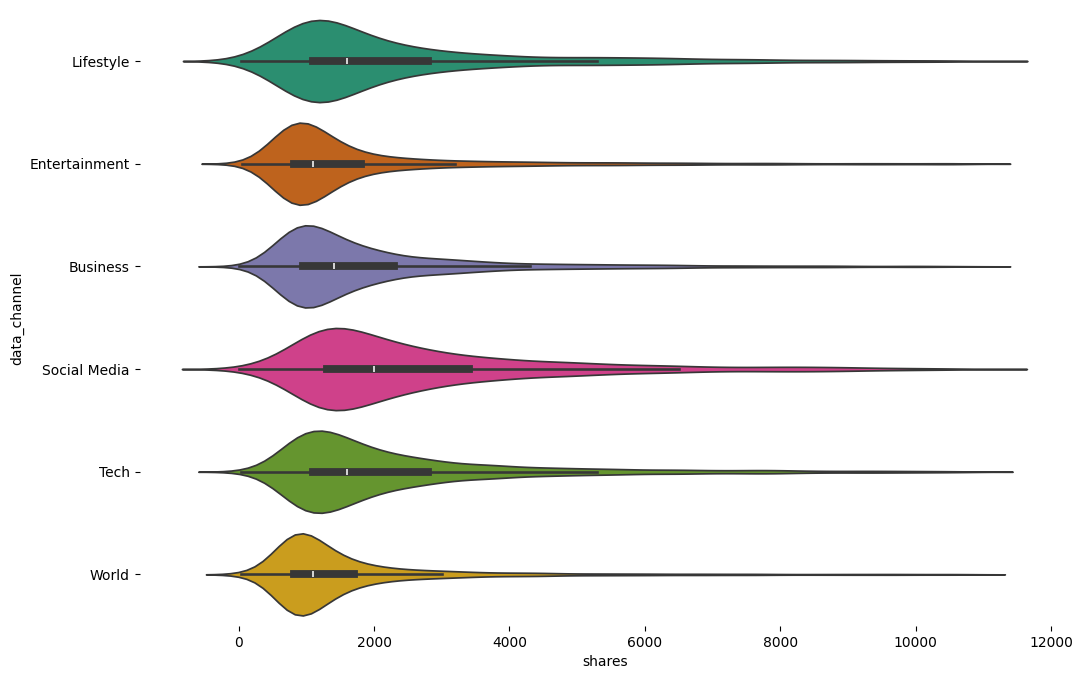

In [396]:
plt.figure(figsize=(12, 8))
sns.violinplot(melted_pop_df, x='shares', y='data_channel', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

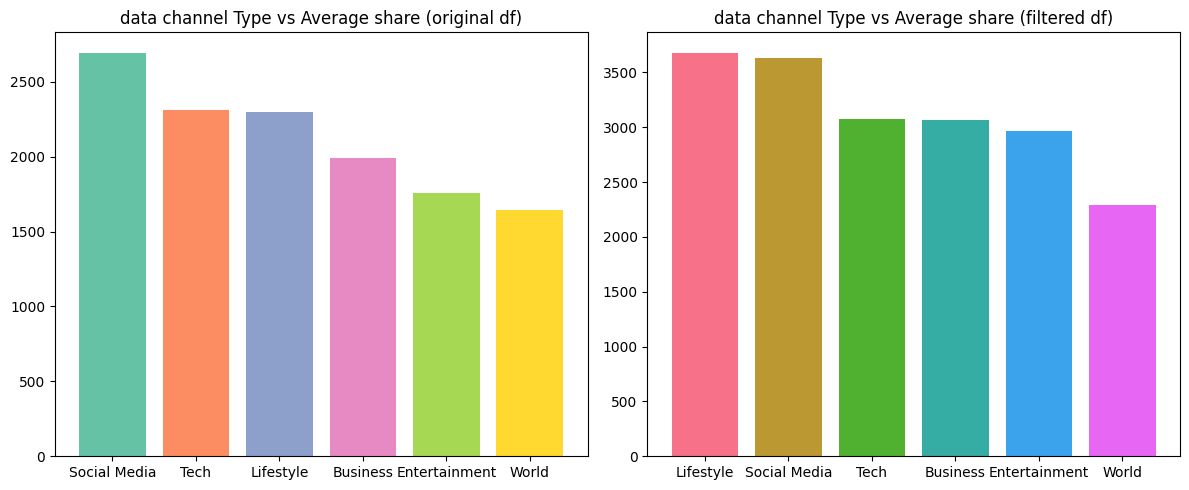

In [397]:
# Compair original vs filtered in average of shares

#original
# melting data frame
melted_original_pop_df = pd.melt(pop_df, id_vars=['shares'], value_vars=[
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed',
    'data_channel_is_tech', 'data_channel_is_world'
], var_name='data_channel', value_name='channel_active')

melted_original_pop_df = melted_original_pop_df[melted_original_pop_df['channel_active'] == 1]

# Map the column names to more readable labels
channel_mapping = {
    'data_channel_is_lifestyle': 'Lifestyle',
    'data_channel_is_entertainment': 'Entertainment',
    'data_channel_is_bus': 'Business',
    'data_channel_is_socmed': 'Social Media',
    'data_channel_is_tech': 'Tech',
    'data_channel_is_world': 'World'
}
melted_original_pop_df['data_channel'] = melted_original_pop_df['data_channel'].map(channel_mapping)

original_df = pd.DataFrame(melted_original_pop_df.groupby(['data_channel']).shares.mean().sort_values(ascending = False))
# Filtered:
filtered_df = pd.DataFrame(melted_pop_df.groupby(['data_channel']).shares.mean().sort_values(ascending = False))

# Plottin
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(filtered_df.index, filtered_df.shares, color=sns.color_palette("Set2"))
plt.title('data channel Type vs Average share (original df)')

plt.subplot(1, 2, 2)
plt.bar(original_df.index, original_df.shares, color=sns.color_palette("husl"))
plt.title('data channel Type vs Average share (filtered df)')

plt.tight_layout()
plt.show()



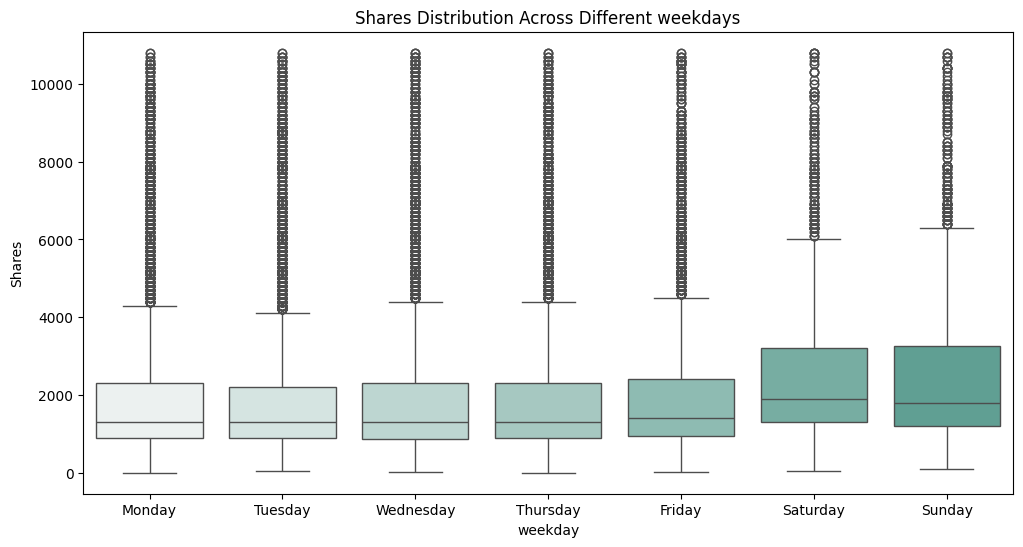

In [398]:
# Visualising days of week
# Create a new column 'weekday' with NaN initially
pop_df_filtered['weekday'] = np.nan

# Whether or not
conditions = [
    pop_df_filtered['weekday_is_monday'] == 1,
    pop_df_filtered['weekday_is_tuesday'] == 1,
    pop_df_filtered['weekday_is_wednesday'] == 1,
    pop_df_filtered['weekday_is_thursday'] == 1,
    pop_df_filtered['weekday_is_friday'] == 1,
    pop_df_filtered['weekday_is_saturday'] == 1,
    pop_df_filtered['weekday_is_sunday'] == 1

]

# Corresponding category names
weekday_name = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

# Use np.select to assign the weekday values based on conditions
pop_df_filtered['weekday'] = np.select(conditions, weekday_name, default=np.nan)

plt.figure(figsize=(12, 6))
sns.boxplot(x='weekday', y='shares', data=pop_df_filtered, palette='light:#5A9')
plt.title('Shares Distribution Across Different weekdays')
plt.xlabel('weekday')
plt.ylabel('Shares')

plt.show()


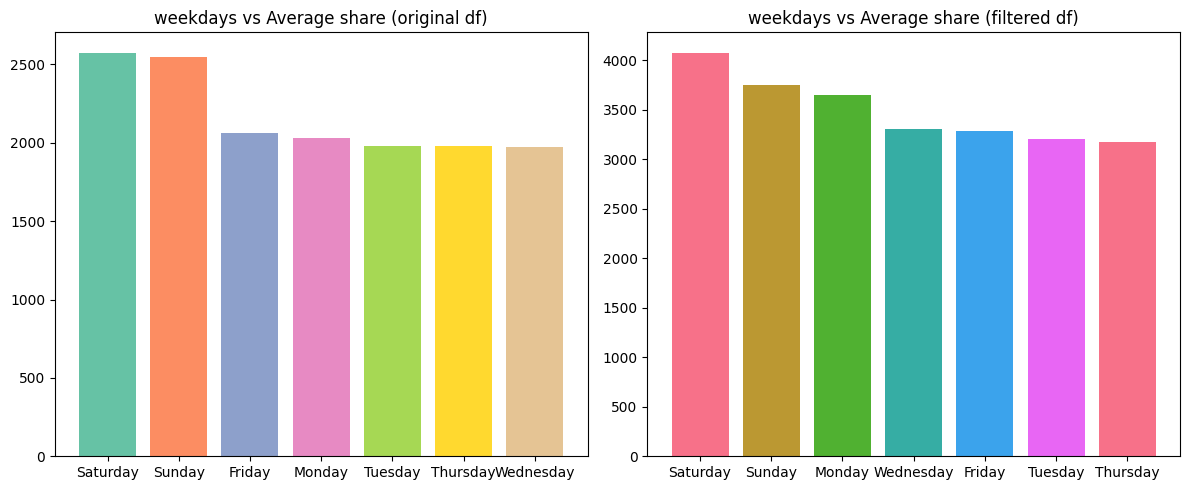

In [399]:
# Compair original vs filtered in average of shares

# Original:
# Create a new column 'weekday' with NaN initially
pop_df['weekday'] = np.nan

# Whether or not
conditions = [
    pop_df['weekday_is_monday'] == 1,
    pop_df['weekday_is_tuesday'] == 1,
    pop_df['weekday_is_wednesday'] == 1,
    pop_df['weekday_is_thursday'] == 1,
    pop_df['weekday_is_friday'] == 1,
    pop_df['weekday_is_saturday'] == 1,
    pop_df['weekday_is_sunday'] == 1

]

# Corresponding category names
weekday_name = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

# Use np.select to assign the weekday values based on conditions
pop_df['weekday'] = np.select(conditions, weekday_name, default=np.nan)

original_df = pd.DataFrame(pop_df.groupby(['weekday']).shares.mean().sort_values(ascending = False))

# Filtered:
filtered_df = pd.DataFrame(pop_df_filtered.groupby(['weekday']).shares.mean().sort_values(ascending = False))

# Plottin
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(filtered_df.index, filtered_df.shares, color=sns.color_palette("Set2"))
plt.title('weekdays vs Average share (original df)')

plt.subplot(1, 2, 2)
plt.bar(original_df.index, original_df.shares, color=sns.color_palette("husl"))
plt.title('weekdays vs Average share (filtered df)')

plt.tight_layout()
plt.show()


In [400]:
# Removing unnecessary feature we made
pop_df.drop(['weekday'],axis="columns",inplace=True)
pop_df_filtered.drop(['weekday'],axis="columns",inplace=True)

#### Visualising numeric data


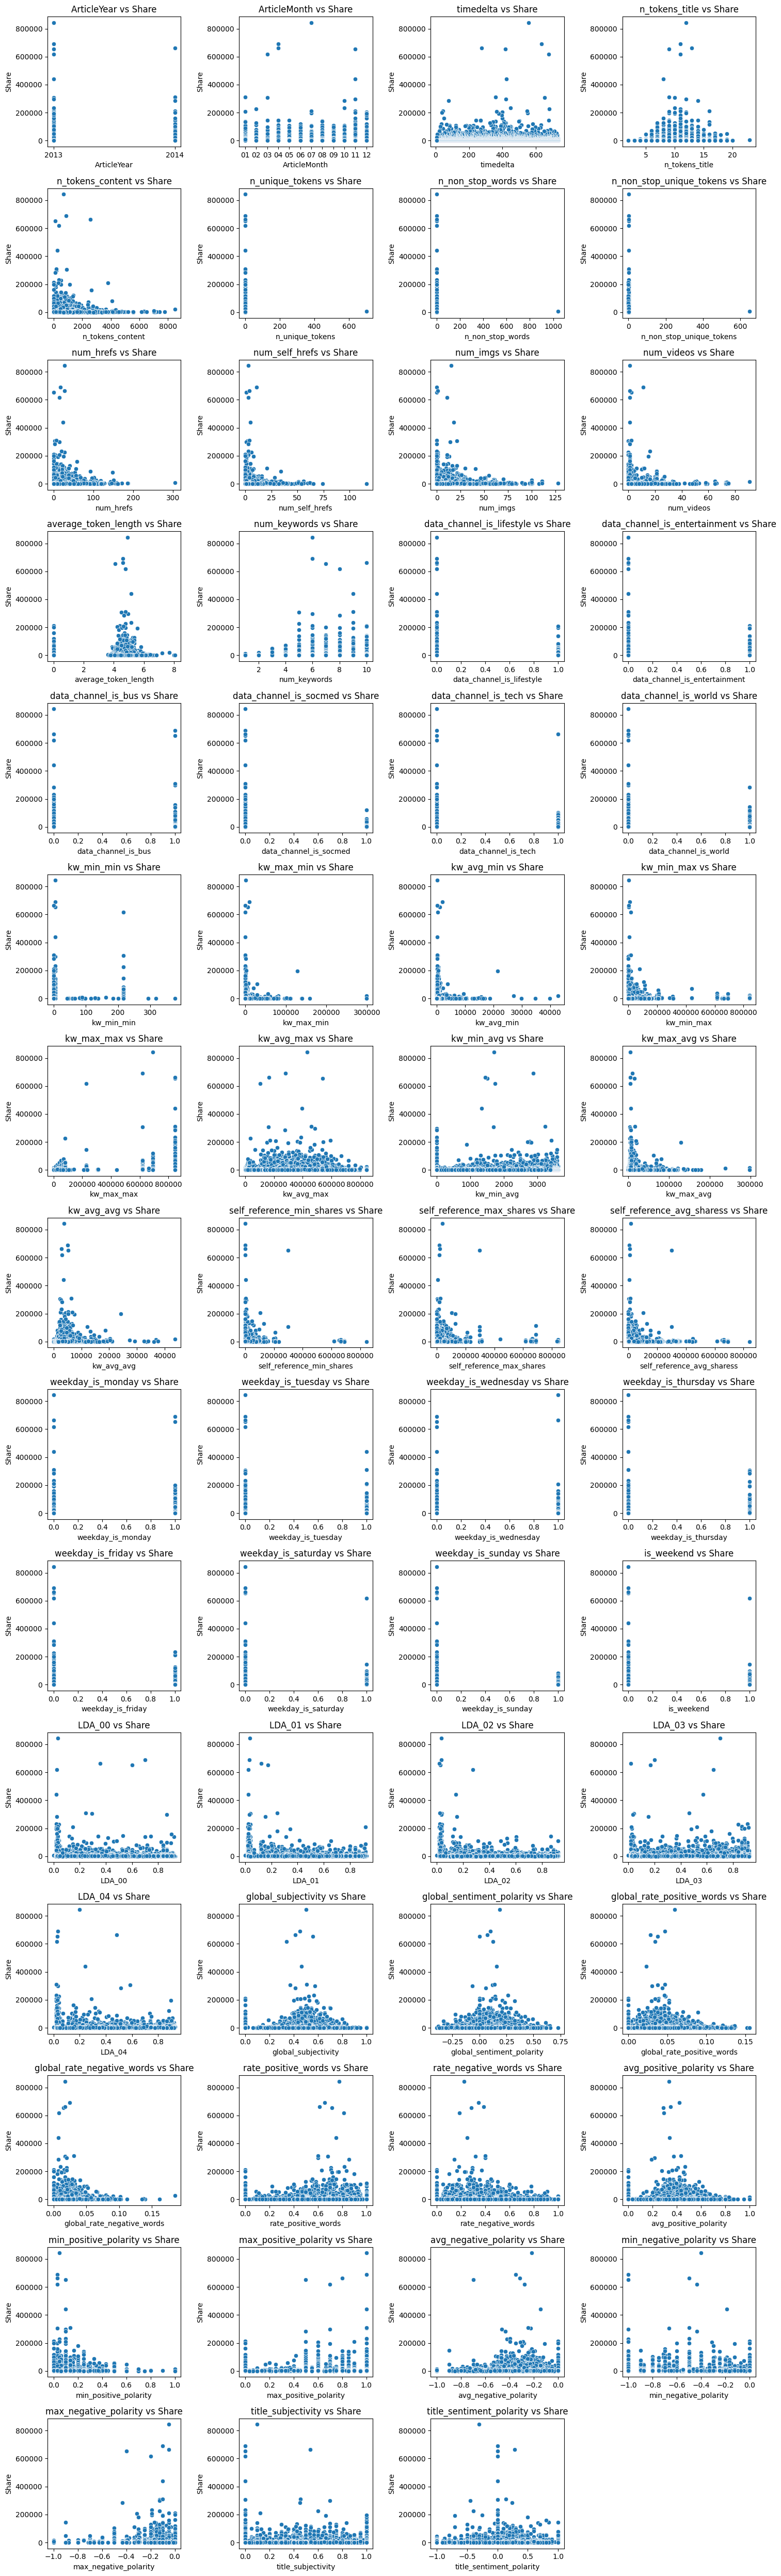

In [401]:
def scatter(x,fig):
    plt.subplot(15,4,fig)
    sns.scatterplot(x=pop_df[x],y=pop_df['shares'])
    plt.title(f"{x} vs Share")
    plt.ylabel('Share')
    plt.xlabel(x)

plt.figure(figsize=(15,50))

for i in range(59):
    scatter(pop_df.columns[i], i+1)

plt.tight_layout()
plt.show()

<Axes: >

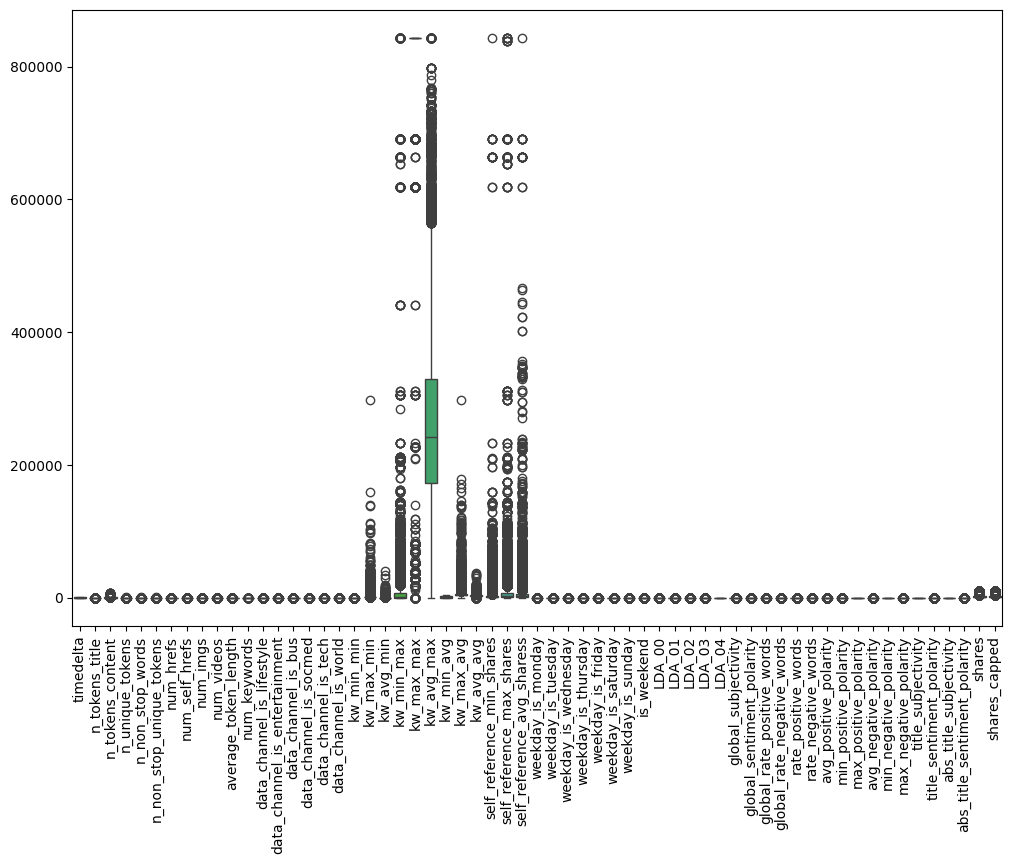

In [402]:
plt.figure(figsize=(12,8))
plt.xticks(rotation=90)
sns.boxplot(pop_df_filtered)

In [403]:
pd.set_option('display.max_rows', None)
pop_df_filtered.corr()['shares'].sort_values()

,shares
LDA_02,-0.129146
data_channel_is_world,-0.121754
data_channel_is_entertainment,-0.079122
rate_negative_words,-0.049060
LDA_01,-0.047940
ArticleMonth,-0.045526
average_token_length,-0.039443
n_tokens_title,-0.033188
weekday_is_wednesday,-0.026857
weekday_is_tuesday,-0.023885


In [404]:
pd.reset_option("max_rows")

#### Inference
As we saw in plots and correlation table, there is no much significant correlation between Shares and our input variables

### List of variables we want to use

    - is_weekend
    - data_channel_is_tech
    - LDA_04
    - data_channel_is_socmed
    - weekday_is_saturday
    - weekday_is_saturday
    - kw_avg_avg
    - weekday_is_sunday
    - num_hrefs
    - global_sentiment_polarity
    - LDA_00
    - kw_min_avg
    - data_channel_is_world
    - LDA_02
    - LDA_01
    - data_channel_is_entertainment
    - rate_negative_words
    - ArticleMonth

In [405]:
lr_df = pop_df_filtered[['shares','is_weekend','data_channel_is_tech','LDA_04','data_channel_is_socmed','weekday_is_saturday',
                         'weekday_is_sunday','num_hrefs','global_sentiment_polarity','LDA_00','kw_min_avg','data_channel_is_world',
                         'LDA_02','LDA_01','data_channel_is_entertainment','rate_negative_words','ArticleMonth']]

## Train-Test Split and feature scaling


In [406]:
from sklearn.model_selection import train_test_split

np.random.seed(0)
df_train, df_test = train_test_split(lr_df, train_size = 0.7, test_size = 0.3, random_state = 100)

In [407]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_vars = ['shares','LDA_04','num_hrefs','global_sentiment_polarity','LDA_00','kw_min_avg',
             'LDA_02','LDA_01','rate_negative_words','ArticleMonth']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

In [408]:
df_train.head()

,shares,is_weekend,data_channel_is_tech,LDA_04,data_channel_is_socmed,weekday_is_saturday,weekday_is_sunday,num_hrefs,global_sentiment_polarity,LDA_00,kw_min_avg,data_channel_is_world,LDA_02,LDA_01,data_channel_is_entertainment,rate_negative_words,ArticleMonth
30986,0.090008,0.0,0.0,0.011431,0.0,0.0,0.0,0.016043,0.457358,0.011431,0.236768,0.0,0.011521,0.955549,1.0,0.260870,0.636364
32981,0.120289,0.0,0.0,0.199384,0.0,0.0,0.0,0.021390,0.386028,0.384112,0.477506,0.0,0.386420,0.016693,0.0,0.545455,0.727273
38706,0.086952,0.0,0.0,0.016673,0.0,0.0,0.0,0.021390,0.314976,0.016674,0.000277,1.0,0.940850,0.016694,0.0,0.545455,1.000000
8672,0.092509,0.0,0.0,0.053346,0.0,0.0,0.0,0.048128,0.528290,0.786341,0.778092,0.0,0.053987,0.053519,0.0,0.166667,0.454545
1917,0.058524,0.0,0.0,0.024011,0.0,0.0,0.0,0.021390,0.328650,0.024097,0.519891,0.0,0.024320,0.024560,0.0,0.466667,0.090909


In [409]:
df_train.describe()

,shares,is_weekend,data_channel_is_tech,LDA_04,data_channel_is_socmed,weekday_is_saturday,weekday_is_sunday,num_hrefs,global_sentiment_polarity,LDA_00,kw_min_avg,data_channel_is_world,LDA_02,LDA_01,data_channel_is_entertainment,rate_negative_words,ArticleMonth
count,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000,26364.000000
mean,0.191291,0.130557,0.189728,0.240928,0.058489,0.062092,0.068465,0.057645,0.457173,0.184109,0.305302,0.220490,0.226803,0.134595,0.177439,0.287764,0.510834
std,0.171908,0.336921,0.392094,0.320079,0.234670,0.241328,0.252546,0.059199,0.085431,0.290354,0.311204,0.414585,0.318208,0.241857,0.382047,0.155518,0.308223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.085563,0.000000,0.000000,0.011434,0.000000,0.000000,0.000000,0.021390,0.402571,0.007554,0.000277,0.000000,0.011521,0.007522,0.000000,0.186218,0.272727
50%,0.129549,0.000000,0.000000,0.026120,0.000000,0.000000,0.000000,0.037433,0.457092,0.016731,0.281761,0.000000,0.024210,0.016700,0.000000,0.280000,0.545455
75%,0.222150,0.000000,0.000000,0.432935,0.000000,0.000000,0.000000,0.069519,0.509254,0.247289,0.561327,0.000000,0.373252,0.145057,0.000000,0.383333,0.818182
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


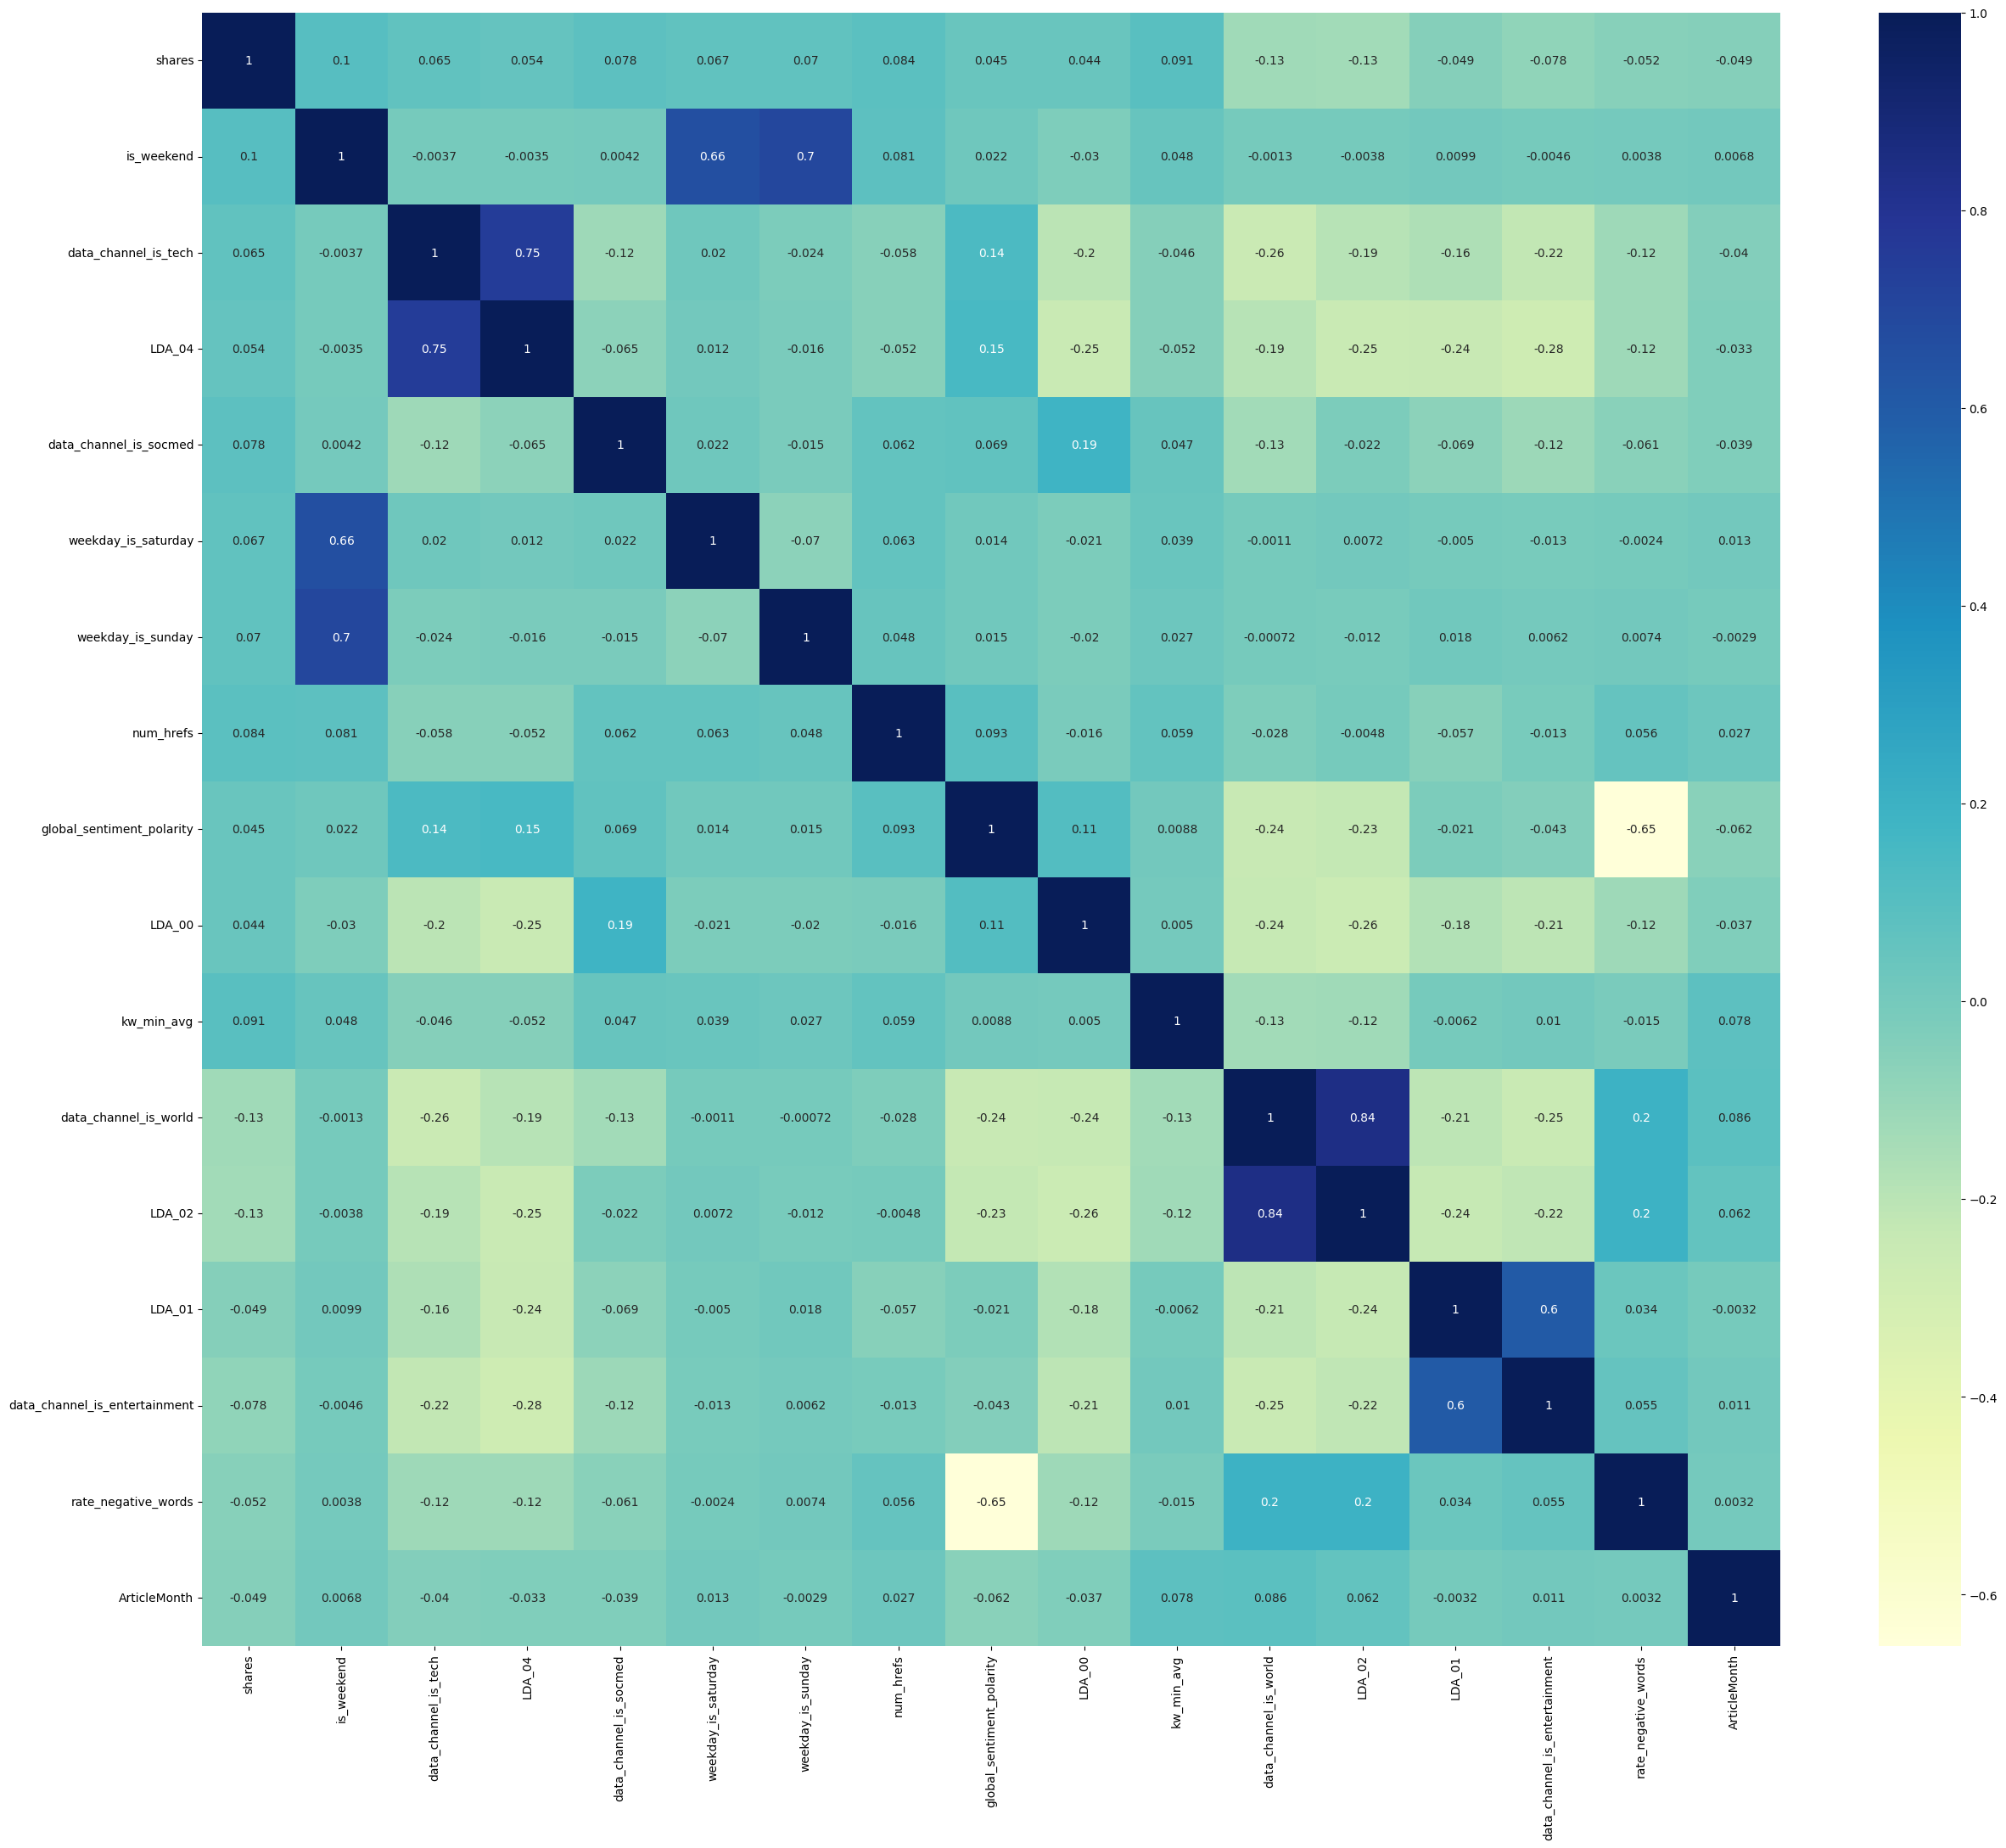

In [410]:
# Heatmap
plt.figure(figsize = (30, 25))
sns.heatmap(df_train.corr(), annot = True, cmap="YlGnBu")
plt.show()

## Model

In [411]:
y_train = df_train.pop('shares')
X_train = df_train

In [412]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
import statsmodels.api as sm

lm = LinearRegression()
lm.fit(X_train,y_train)
rfe = RFE(lm)
rfe = rfe.fit(X_train, y_train)
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('is_weekend', True, 1),
 ('data_channel_is_tech', False, 5),
 ('LDA_04', False, 6),
 ('data_channel_is_socmed', False, 2),
 ('weekday_is_saturday', True, 1),
 ('weekday_is_sunday', True, 1),
 ('num_hrefs', True, 1),
 ('global_sentiment_polarity', True, 1),
 ('LDA_00', False, 8),
 ('kw_min_avg', False, 3),
 ('data_channel_is_world', False, 9),
 ('LDA_02', True, 1),
 ('LDA_01', False, 7),
 ('data_channel_is_entertainment', True, 1),
 ('rate_negative_words', True, 1),
 ('ArticleMonth', False, 4)]

In [413]:
X_train.columns[rfe.support_]

Index(['is_weekend', 'weekday_is_saturday', 'weekday_is_sunday', 'num_hrefs',
       'global_sentiment_polarity', 'LDA_02', 'data_channel_is_entertainment',
       'rate_negative_words'],
      dtype='object')

In [414]:
X_train_rfe = X_train[X_train.columns[rfe.support_]]
X_train_rfe.head()

,is_weekend,weekday_is_saturday,weekday_is_sunday,num_hrefs,global_sentiment_polarity,LDA_02,data_channel_is_entertainment,rate_negative_words
30986,0.0,0.0,0.0,0.016043,0.457358,0.011521,1.0,0.260870
32981,0.0,0.0,0.0,0.021390,0.386028,0.386420,0.0,0.545455
38706,0.0,0.0,0.0,0.021390,0.314976,0.940850,0.0,0.545455
8672,0.0,0.0,0.0,0.048128,0.528290,0.053987,0.0,0.166667
1917,0.0,0.0,0.0,0.021390,0.328650,0.024320,0.0,0.466667


In [415]:
def build_model(X,y):
    X = sm.add_constant(X)
    lm = sm.OLS(y,X).fit()
    print(lm.summary())
    return X

def checkVIF(X):
    vif = pd.DataFrame()
    vif['Features'] = X.columns
    vif['VIF'] = [VIF(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    return(vif)

### Model 1

In [416]:
X_train_new = build_model(X_train_rfe, y_train)

                            OLS Regression Results                            
Dep. Variable:                 shares   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     180.6
Date:                Fri, 15 Nov 2024   Prob (F-statistic):          1.73e-262
Time:                        20:43:07   Log-Likelihood:                 9631.0
No. Observations:               26364   AIC:                        -1.925e+04
Df Residuals:                   26356   BIC:                        -1.918e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

`is_weekend` , `weekday_is_saturday` and `weekday_is_sunday` with high "p-value"

In [417]:
X_train_new = X_train_rfe.drop(["is_weekend"], axis = 1)

### Model 2

In [418]:
X_train_new = build_model(X_train_new,y_train)

                            OLS Regression Results                            
Dep. Variable:                 shares   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     180.6
Date:                Fri, 15 Nov 2024   Prob (F-statistic):          1.70e-262
Time:                        20:43:07   Log-Likelihood:                 9631.0
No. Observations:               26364   AIC:                        -1.925e+04
Df Residuals:                   26356   BIC:                        -1.918e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [419]:
checkVIF(X_train_new)

,Features,VIF
0,const,82.69
4,global_sentiment_polarity,1.83
7,rate_negative_words,1.79
5,LDA_02,1.12
6,data_channel_is_entertainment,1.06
3,num_hrefs,1.04
1,weekday_is_saturday,1.01
2,weekday_is_sunday,1.01


###  Residual Analysis of Model

In [420]:
lm = sm.OLS(y_train,X_train_new).fit()
y_train_share = lm.predict(X_train_new)

Text(0.5, 0, 'Errors')

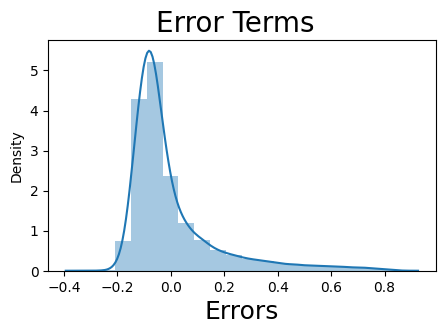

In [421]:
# Plot error
fig = plt.figure(figsize = (5, 3))
sns.distplot((y_train - y_train_share), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)
plt.xlabel('Errors', fontsize = 18)

## Prediction

In [422]:
num_vars = ['shares','LDA_04','num_hrefs','global_sentiment_polarity','LDA_00','kw_min_avg',
             'LDA_02','LDA_01','rate_negative_words','ArticleMonth']

df_test[num_vars] = scaler.fit_transform(df_test[num_vars])

In [423]:
y_test = df_test.pop('shares')
X_test = df_test

In [424]:
# predictions
X_train_new = X_train_new.drop('const',axis=1)
X_test_new = X_test[X_train_new.columns]
X_test_new = sm.add_constant(X_test_new)

y_pred = lm.predict(X_test_new)

In [425]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.03847393754685913

In [426]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                 shares   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     180.6
Date:                Fri, 15 Nov 2024   Prob (F-statistic):          1.70e-262
Time:                        20:43:08   Log-Likelihood:                 9631.0
No. Observations:               26364   AIC:                        -1.925e+04
Df Residuals:                   26356   BIC:                        -1.918e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         